<br>
<a href="https://www.nvidia.com/en-us/training/">
    <div style="width: 55%; background-color: white; margin-top: 50px;">
    <img src="https://dli-lms.s3.amazonaws.com/assets/general/nvidia-logo.png"
         width="300" style="margin: 0px -25px -5px;"/>
    </div>
</a>

# Notebook 0: Preprocessing the Ahmed Body Dataset for Transolver & GeoTransolver

| | Notebook | What it covers |
|---|---|---|
| **← You are here** | **0 — Preprocessing** | **VTP/STL → Zarr, per-case velocity, normalization** |
| | 1 — Transformers & Bottleneck | Why $O(N^2)$ attention fails on large meshes |
| | 2 — Understanding Transolver | Physics-Attention: Slice → Aggregate → Attend → Deslice |
| | 3 — Training Transolver | `TransolverDataPipe` training loop, slice visualization |
| | 4 — Understanding GALE & GeoTransolver | GALE cross-attention, geometry injection |
| | 5 — Training GeoTransolver | Same pipeline, `broadcast_global_features=False`, GALE |

This notebook creates the **Zarr dataset** that both Notebook 3 and Notebook 5 share.  
Run it **once** — both training notebooks will read the same output directory.


## Introduction

The Ahmed body is a simplified vehicle geometry that has become the gold standard for validating automotive CFD simulations. The dataset hosted on NGC contains 508 simulations spanning variations in geometry and — critically — **inlet velocity**, which differs from case to case.

### Why a dedicated preprocessing notebook?

Transolver and GeoTransolver both use **`TransolverDataPipe`** as their data pipeline, which reads data in **Zarr** format. This notebook is the one-time conversion step:

```
VTP  (CFD surface fields)  ┐
STL  (body geometry)       ├──► Zarr ──► Notebooks 3 & 5
Info (per-case velocity)   ┘
```

### Physical non-dimensionalization

Before saving, we non-dimensionalize the surface fields by the **dynamic pressure** $q = \rho \cdot U^2$ of each case:

$$C_p = \frac{p}{\rho U^2}, \quad C_f = \frac{\tau_w}{\rho U^2}$$

This ensures that fields from different inlet-velocity cases are on a comparable scale regardless of flow speed. Without this step, a case at $U = 60$ m/s has fields $\sim9\times$ larger than one at $U = 20$ m/s, which would cause the z-score normalization statistics to be dominated by high-velocity cases.

After non-dimensionalization the pressure coefficient $C_p$ sits in roughly $[-1.2, 0.4]$ across all cases, as confirmed by the DoMINO preprocessing notebook.

### Per-case `stream_velocity` and reference normalization

Following the same convention as the DoMINO pipeline, global flow parameters are stored both as **per-case actual values** and **reference values**:

| Key saved in Zarr | Value | Role |
|---|---|---|
| `stream_velocity` | $U / U_{\text{ref}}$ | normalized inflow speed |
| `air_density` | $\rho / \rho_{\text{ref}}$ | normalized air density |

Dividing by reference values keeps the model inputs O(1) regardless of units or magnitude, matching the approach used in `GLOBAL_PARAMS_REFERENCE` in the DoMINO preprocessing notebook.


## Step 1: Import Libraries and Start Display Server


In [1]:
import os
import re
import random
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path
from typing import Dict, List, Optional, Union

import numpy as np
import pyvista as pv
import zarr
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.amp import autocast, GradScaler

# PhysicsNeMo — only the low-level zarr reader is needed here
from physicsnemo.datapipes.cae.cae_dataset import CAEDataset
from physicsnemo.distributed import DistributedManager

# Reproducibility
np.random.seed(42)
random.seed(42)

# Start a virtual framebuffer so PyVista can render on headless servers
# Headless PyVista setup
os.environ.setdefault("XDG_RUNTIME_DIR", "/tmp")
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")

try:
    # Newer PyVista versions may not expose start_xvfb at the top level
    try:
        pv.start_xvfb()
    except AttributeError:
        from pyvista.plotting.utilities.xvfb import start_xvfb
        start_xvfb()

    print("✓ Xvfb started.")
except Exception as e:
    print(f"Warning: Could not start Xvfb: {e}")
    print("Continuing with PyVista off-screen rendering.")

pv.OFF_SCREEN = True

print("✓ Headless PyVista configured.")


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926
  dispatch key: ADInplaceOrView
  previous kernel: no d

✓ Xvfb started.
✓ Headless PyVista configured.


## Step 2: Configuration

Set all paths and physical parameters here before running any other cell.

### `GLOBAL_PARAMS_TYPES` and `GLOBAL_PARAMS_REFERENCE`

Following the DoMINO preprocessing convention, we define:

- **`GLOBAL_PARAMS_TYPES`** — whether each global parameter is a `"scalar"` or `"vector"`.
- **`GLOBAL_PARAMS_REFERENCE`** — reference values used to normalize the global parameters  
  so the model always receives O(1) conditioning inputs.

### No manual split needed

The Ahmed body dataset already ships with pre-defined `train/`, `validation/`, and  
`test/` folders. We process each directly — no shuffling or ratio-based splitting.  
This mirrors the DoMINO preprocessing approach.

### Physical non-dimensionalization reference

`surface_fields` are divided by $\rho \cdot U^2$ of each case before saving,  
so z-score statistics computed later are over already-comparable values.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path("/workspace/physicsnemo_ahmed_body_dataset_vv1/dataset")

# Output Zarr root — shared by Notebook 3 and Notebook 5
ZARR_OUTPUT_DIR    = DATA_DIR / "ahmed_body_zarr"
TRAIN_ZARR_DIR     = ZARR_OUTPUT_DIR / "train"
VAL_ZARR_DIR       = ZARR_OUTPUT_DIR / "validation"
TEST_ZARR_DIR      = ZARR_OUTPUT_DIR / "test"

for d in [TRAIN_ZARR_DIR, VAL_ZARR_DIR, TEST_ZARR_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Global parameter types and reference values ────────────────────────────────
# Matches the DoMINO preprocessing convention.
GLOBAL_PARAMS_TYPES     = {"inlet_velocity": "scalar", "air_density": "scalar"}
GLOBAL_PARAMS_REFERENCE = {"inlet_velocity": 60.0, "air_density": 1.226}

# Constant air density for this dataset (kg/m³).
# inlet_velocity is read per-case from the info files.
AIR_DENSITY = 1.184

print("=== Configuration ===")
print(f"Dataset root  : {DATA_DIR}")
print(f"Train  Zarr   : {TRAIN_ZARR_DIR}")
print(f"Val    Zarr   : {VAL_ZARR_DIR}")
print(f"Test   Zarr   : {TEST_ZARR_DIR}")
print(f"Air density   : {AIR_DENSITY} kg/m³")
print(f"\nGlobal parameter reference values:")
for k, v in GLOBAL_PARAMS_REFERENCE.items():
    print(f"  {k:20s}: {v}")


=== Configuration ===
Dataset root  : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset
Train  Zarr   : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/train
Val    Zarr   : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/validation
Test   Zarr   : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/test
Air density   : 1.184 kg/m³

Global parameter reference values:
  inlet_velocity      : 60.0
  air_density         : 1.226


## Step 3: Exploring the Ahmed Body Dataset

Before converting anything, let's take a quick look at what we have.

### Data structure

The dataset is organized into three splits:

```
dataset/
├── train/                  ← VTP files (CFD surface fields)
├── train_info/             ← TXT files (per-case global parameters, incl. inlet velocity)
├── train_stl_files/        ← STL files (body geometry)
├── validation/
├── validation_info/
├── validation_stl_files/
├── test/
├── test_info/
└── test_stl_files/
```

Each VTP file stores:
- **Geometry:** 3D surface point coordinates and mesh connectivity
- **Fields:** pressure `p` and wall shear stress `wallShearStress` at every surface point

Each info file stores per-case flow parameters (inlet velocity, air density) as plain text.


In [3]:
# ── Dataset inventory ──────────────────────────────────────────────────────────
print(f"Dataset root: {DATA_DIR}")
#total_bytes = sum(f.stat().st_size for f in DATA_DIR.rglob("*") if f.is_file())
#print(f"Total dataset size: {total_bytes / 1024**3:.2f} GB\n")

for split in ["train", "validation", "test"]:
    vtp_dir = DATA_DIR / split
    stl_dir = DATA_DIR / f"{split}_stl_files"
    inf_dir = DATA_DIR / f"{split}_info"

    vtp_count = len(list(vtp_dir.glob("*.vtp")))  if vtp_dir.exists() else 0
    stl_count = len(list(stl_dir.glob("*.stl")))  if stl_dir.exists() else 0
    inf_count = len(list(inf_dir.glob("*")))       if inf_dir.exists() else 0

    print(f"{split.capitalize():12s}: {vtp_count:4d} VTP  |  {stl_count:4d} STL  |  {inf_count:4d} info files")


Dataset root: /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset
Train       :  408 VTP  |   408 STL  |   408 info files
Validation  :   50 VTP  |    50 STL  |    50 info files
Test        :   50 VTP  |    50 STL  |    50 info files


### Inspecting a Single VTP File

Let's examine what fields are stored in a representative VTP file.


In [4]:
# Pick a representative VTP file
sample_vtp_path = next((DATA_DIR / "train").glob("*.vtp"))
mesh_sample = pv.read(sample_vtp_path)

print(f"File: {sample_vtp_path.name}")
print(f"  Surface points : {mesh_sample.n_points:,}")
print(f"  Surface cells  : {mesh_sample.n_cells:,}")
print(f"  Surface area   : {mesh_sample.area:.3f} m²\n")

print("Point data fields:")
for name in mesh_sample.point_data.keys():
    arr = mesh_sample.point_data[name]
    print(f"  {name:20s}  shape={str(arr.shape):12s}  "
          f"range=[{arr.min():10.4f}, {arr.max():10.4f}]")


File: case894.vtp
  Surface points : 54,187
  Surface cells  : 53,851
  Surface area   : 0.639 m²

Point data fields:
  k                     shape=(54187,)      range=[    0.0669,    57.8012]
  nut                   shape=(54187,)      range=[    0.0000,     0.0003]
  omega                 shape=(54187,)      range=[ 3014.5183, 540073.2500]
  p                     shape=(54187,)      range=[-3887.6392,  1651.2150]
  yPlus                 shape=(54187,)      range=[    1.6152,   442.2095]
  U                     shape=(54187, 3)    range=[    0.0000,     0.0000]
  wallShearStress       shape=(54187, 3)    range=[  -21.0313,     8.4558]


### Reading Data from EnSight Files

> **Format flexibility:** This pipeline is not restricted to VTP files.
> Any solver that exports to **EnSight Gold** format (`.encas` / `.case`) can
> feed directly into this notebook — no conversion step required.
>
> EnSight is the native export format of many commercial and open-source CFD
> solvers: Fluent, CFX, Star-CCM+, OpenFOAM (`foamToEnsight`), and others.

The cell below uses VTK's `vtkGenericEnSightReader` — the same reader used in
the production EnSight→Zarr conversion script — to:

1. Locate a `.encas` / `.case` file and enumerate **all available time steps**
2. Enable every part and variable (`ReadAllVariablesOn`)
3. Read one time step and flatten the **MultiBlock** output into named meshes
4. Print a complete **field inventory** (shape, min, max) for each part
5. Extract the largest surface part and **visualise one scalar field** with
   matplotlib

Point to your own data by changing `ENSIGHT_ROOT` (or `ENSIGHT_CASE_PATH`) below.

✓ Case file : /workspace/ansys/data/workshop/G11/G11.encas
  Time steps : 80  (t_first=0.250448, t_last=20)
  Variables  : ['pressure', 'x_velocity', 'y_velocity', 'z_velocity', 'epoxy_vof', 'velocity']

Parsing geometry : G11.geo ...
  Parts   : 7
  Points  : 1,360,225
  Cells   : 513,669
    part 31:  105,678 pts  [nsided(52262)]
    part 32:  105,585 pts  [nsided(75857)]
    part 33:    1,780 pts  [nsided(1294)]
    part 34:  105,504 pts  [nsided(52175)]
    part 35:    2,428 pts  [nsided(1812)]
    part 36:    1,134 pts  [nsided(846)]
    part 122: 1,038,116 pts  [nfaced(329423)]

Reading epoxy_vof  step=20  (t = 5.25)
  File  : G1108235.scl5
  Range : [0.0000, 1.0000]
  Non-zero (>0.01): 298,784 / 513,669 cells

Computing 513,669 cell centroids ...
  Shape  : (513669, 3)
  Bounds : x=[-0.000, 0.007]  y=[0.000, 0.000]  z=[-0.001, 0.007]


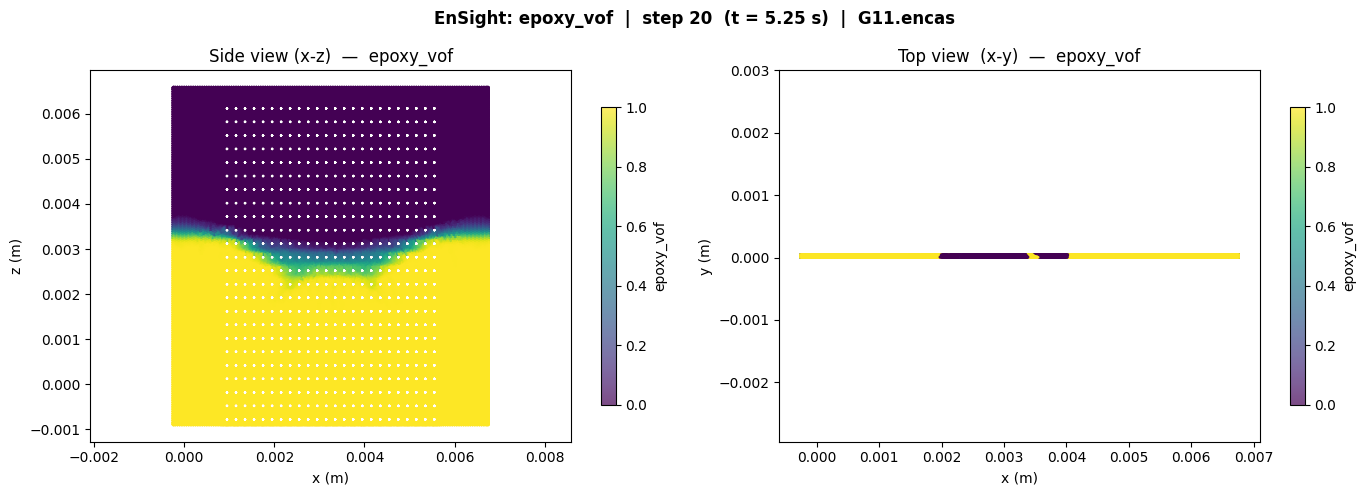


Note: parse_case_file + parse_geo_binary + parse_variable_binary are the
exact reader functions used in the production EnSight→Zarr pipeline.


In [6]:
# ─── Reading Data from EnSight Gold Binary Files ──────────────────────────────
# Uses the same hand-written binary parser as the production EnSight → Zarr
# pipeline — bypasses vtkGenericEnSightReader, which fails on non-standard
# G1100448-style file numbering used by this dataset.
#
# Reader workflow:
#   parse_case_file       → locate .geo + variable files, extract time values
#   parse_geo_binary      → read binary geometry: points + connectivity per part
#   parse_variable_binary → per-cell scalar values at one time step
#   compute_cell_centroids → cell centroids for scatter visualisation (no VTK grid needed)

import re, struct
from collections import defaultdict

# ── Configuration ─────────────────────────────────────────────────────────────
ENSIGHT_ROOT      = Path("/workspace/ansys/data/workshop")
ENSIGHT_CASE_PATH = None   # leave None → auto-discovered

READ_STEP_IDX = 20          # time-step index to visualise (0-indexed)
FIELD_TO_PLOT = "epoxy_vof" # scalar field name (must be in .encas VARIABLE section)


# ── Priority-aware case-file discovery ────────────────────────────────────────
def find_ensight_case(root):
    """
    Locate the main (multi-timestep) .encas file under root.
    Priority mirrors the production pipeline:
      1. {dir_name}.encas          e.g. G11/G11.encas   (all 80 time steps)
      2. {dir_name}_ensigh_export.encas
      3. any .encas whose stem has no dash  (avoids G11-0.00.encas)
      4. first .encas / .case found (last resort)
    """
    root = Path(root)
    if not root.exists():
        return None
    all_enc = sorted(root.rglob("*.encas")) + sorted(root.rglob("*.case"))
    if not all_enc:
        return None
    by_dir = defaultdict(list)
    for f in all_enc:
        by_dir[f.parent].append(f)
    best = []
    for parent, files in sorted(by_dir.items()):
        dn = parent.name
        exact = [f for f in files if f.name == f"{dn}.encas"]
        if exact:  best.append(exact[0]);  continue
        xport = [f for f in files if f.name == f"{dn}_ensigh_export.encas"]
        if xport: best.append(xport[0]); continue
        ndash = [f for f in files if "-" not in f.stem and f.suffix == ".encas"]
        if ndash: best.append(ndash[0]); continue
        best.append(files[0])
    return best[0] if best else None


# ── Low-level binary I/O ──────────────────────────────────────────────────────
def _read_80(f):
    """Read one 80-byte EnSight record; return stripped ASCII string."""
    return f.read(80).decode('ascii', errors='replace').strip('\x00 ').strip()

def _read_int(f):
    return struct.unpack('<i', f.read(4))[0]

def _read_ints(f, n):
    return np.frombuffer(f.read(4 * n), dtype='<i4')

def _read_floats(f, n):
    return np.frombuffer(f.read(4 * n), dtype='<f4')

# EnSight standard element types → nodes per cell
STD_ELEM_MAP = {
    'point':    1,  'bar2':     2,  'tria3':    3,  'quad4':    4,
    'tetra4':   4,  'pyramid5': 5,  'penta6':   6,  'hexa8':    8,
}
KNOWN_ELEM_TYPES = set(STD_ELEM_MAP) | {'nfaced', 'nsided'}


# ── Case file parser ───────────────────────────────────────────────────────────
def parse_case_file(case_path):
    """
    Parse an EnSight Gold .encas / .case ASCII header.
    Returns dict with:
      geometry         : relative path to .geo file
      variables        : list of (kind, name, file_pattern)
      filename_numbers : list[int]   — maps step index to data file number
      time_values      : list[float] — physical simulation times
    """
    with open(case_path, 'r') as f:
        text = f.read()
    info = {'geometry': None, 'variables': [],
            'filename_numbers': [], 'time_values': []}
    m = re.search(
        r'^\s*model:\s*(?:\d+\s+)?["\']?([^"\'\n]+?)["\']?\s*$',
        text, re.MULTILINE | re.IGNORECASE)
    if m:
        info['geometry'] = m.group(1).strip()
    var_re = re.compile(
        r'^\s*(scalar|vector|tensor)\s+per\s+(?:element|node)\s*:\s*\d+\s+(\S+)\s+["\']([^"\']+)["\']',
        re.MULTILINE | re.IGNORECASE)
    for kind, name, pattern in var_re.findall(text):
        info['variables'].append((kind.lower(), name, pattern))
    ts1 = re.search(
        r'time set:\s*1\b.*?number of steps:\s*(\d+).*?'
        r'(?:filename numbers:\s*(.*?))?'
        r'time values:\s*(.*?)(?=\n\s*(?:time set:|FILE|SCRIPTS|\Z))',
        text, re.DOTALL | re.IGNORECASE)
    if ts1:
        if ts1.group(2):
            info['filename_numbers'] = [int(x) for x in re.findall(r'\d+', ts1.group(2))]
        info['time_values'] = [float(x) for x in
            re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', ts1.group(3))]
    return info


def expand_pattern(pattern, number):
    """Replace * wildcard in an EnSight file-name pattern with a zero-padded number."""
    m = re.search(r'\*+', pattern)
    if not m:
        return pattern
    width = len(m.group(0))
    return pattern[:m.start()] + str(number).zfill(width) + pattern[m.end():]


# ── Geometry binary parser ────────────────────────────────────────────────────
def parse_geo_binary(geo_path):
    """
    Parse an EnSight Gold binary .geo file.
    Returns {part_id: {'points': ndarray(N,3), 'blocks': [...]}} where each
    block dict contains kind ('std'/'nfaced'/'nsided'), etype, n_elements,
    and kind-specific connectivity arrays.
    Handles standard (hex/tet/…), polyhedral (nfaced), and polygon (nsided) elements.
    """
    parts = {}
    with open(geo_path, 'rb') as f:
        _ = _read_80(f)                        # "C Binary"
        _ = _read_80(f)                        # description 1
        _ = _read_80(f)                        # description 2
        node_id_line = _read_80(f)             # "node id given/ignore/assign/off"
        elem_id_line = _read_80(f)             # "element id given/ignore/assign/off"
        node_id_mode = node_id_line.split()[-1].lower() if node_id_line else 'off'
        elem_id_mode = elem_id_line.split()[-1].lower() if elem_id_line else 'off'
        peek = f.read(80)
        if peek:
            ps = peek.decode('ascii', errors='replace').strip('\x00 ').strip().lower()
            if ps.startswith('extents'):
                _ = _read_floats(f, 6)         # skip bounding box (6 floats)
            else:
                f.seek(-80, 1)                 # not extents → put it back
        while True:
            header = f.read(80)
            if not header or len(header) < 80:
                break
            hs = header.decode('ascii', errors='replace').strip('\x00 ').strip()
            if not hs.lower().startswith('part'):
                break
            part_id    = _read_int(f)
            _          = _read_80(f)           # part description
            coord_line = _read_80(f)
            if not coord_line.lower().startswith('coordinates'):
                break
            n_nodes = _read_int(f)
            if node_id_mode in ('given', 'ignore'):
                _ = _read_ints(f, n_nodes)
            xs = _read_floats(f, n_nodes)
            ys = _read_floats(f, n_nodes)
            zs = _read_floats(f, n_nodes)
            points = np.column_stack([xs, ys, zs]).astype(np.float64)
            blocks = []
            while True:
                pos = f.tell()
                nxt = f.read(80)
                if not nxt or len(nxt) < 80:
                    break
                ns = nxt.decode('ascii', errors='replace').strip('\x00 ').strip().lower()
                if ns.startswith('part'):
                    f.seek(pos); break
                etype = ns.split()[0] if ns else ''
                if etype not in KNOWN_ELEM_TYPES:
                    f.seek(pos); break
                n_elem = _read_int(f)
                if elem_id_mode in ('given', 'ignore'):
                    _ = _read_ints(f, n_elem)
                if etype in STD_ELEM_MAP:
                    npc  = STD_ELEM_MAP[etype]
                    conn = _read_ints(f, n_elem * npc).reshape(n_elem, npc).astype(np.int64) - 1
                    blocks.append({'kind': 'std', 'etype': etype,
                                   'n_elements': n_elem, 'conn': conn})
                elif etype == 'nfaced':
                    fpe = _read_ints(f, n_elem).astype(np.int32).copy()
                    npf = _read_ints(f, int(fpe.sum())).astype(np.int32).copy()
                    fc  = _read_ints(f, int(npf.sum())).astype(np.int64).copy() - 1
                    blocks.append({'kind': 'nfaced', 'etype': etype, 'n_elements': n_elem,
                                   'faces_per_elem': fpe, 'nodes_per_face': npf,
                                   'face_conn': fc})
                elif etype == 'nsided':
                    npe  = _read_ints(f, n_elem).astype(np.int32).copy()
                    conn = _read_ints(f, int(npe.sum())).astype(np.int64).copy() - 1
                    blocks.append({'kind': 'nsided', 'etype': etype, 'n_elements': n_elem,
                                   'nodes_per_elem': npe, 'conn': conn})
            parts[part_id] = {'points': points, 'blocks': blocks}
    return parts


# ── Variable binary parser ────────────────────────────────────────────────────
def parse_variable_binary(var_path, parts):
    """
    Parse one EnSight Gold binary scalar variable file.
    Returns {part_id: np.ndarray(n_cells,)} of float32 values in element order.
    """
    data = {}
    with open(var_path, 'rb') as f:
        _ = _read_80(f)             # description line
        while True:
            header = f.read(80)
            if not header or len(header) < 80:
                break
            hs = header.decode('ascii', errors='replace').strip('\x00 ').strip()
            if not hs.lower().startswith('part'):
                break
            part_id     = _read_int(f)
            part_blocks = parts.get(part_id, {}).get('blocks', [])
            part_vals   = []
            for blk in part_blocks:
                _    = _read_80(f)                         # element-type label
                vals = _read_floats(f, blk['n_elements'])
                part_vals.append(np.asarray(vals, dtype=np.float32))
            data[part_id] = (np.concatenate(part_vals) if part_vals
                             else np.zeros(0, dtype=np.float32))
    return data


# ── Cell centroid helper ──────────────────────────────────────────────────────
def compute_cell_centroids(parts):
    """
    Compute the centroid (mean node position) of every cell across all parts.
    Iteration order: sorted(part_ids) then blocks in sequence — identical to
    parse_variable_binary, so centroid[i] corresponds to field_value[i].
    """
    all_c = []
    for pid in sorted(parts.keys()):
        pts = parts[pid]['points']
        for blk in parts[pid]['blocks']:
            kind = blk['kind']
            if kind == 'std':
                conn = blk['conn']                         # (n_elem, npc)
                all_c.append(pts[conn].mean(axis=1))       # (n_elem, 3)
            elif kind == 'nsided':
                npe  = blk['nodes_per_elem'].astype(np.int64)
                conn = blk['conn']
                cum  = np.concatenate([[0], np.cumsum(npe)])
                n_e  = blk['n_elements']
                all_c.append(np.array([
                    pts[conn[cum[i]:cum[i+1]]].mean(axis=0) for i in range(n_e)
                ]))
            elif kind == 'nfaced':
                fpe    = blk['faces_per_elem'].astype(np.int64)
                npf    = blk['nodes_per_face'].astype(np.int64)
                fc     = blk['face_conn']
                cum_f  = np.concatenate([[0], np.cumsum(fpe)])
                cum_fn = np.concatenate([[0], np.cumsum(npf)])
                n_e    = blk['n_elements']
                all_c.append(np.array([
                    pts[np.unique(fc[cum_fn[cum_f[i]]:cum_fn[cum_f[i+1]]])].mean(axis=0)
                    for i in range(n_e)
                ]))
    return np.vstack(all_c) if all_c else np.zeros((0, 3))


# ─────────────────────────────────────────────────────────────────────────────
# Main: read → inspect → visualise
# ─────────────────────────────────────────────────────────────────────────────

# 1. Locate case file ──────────────────────────────────────────────────────────
if ENSIGHT_CASE_PATH is None:
    ENSIGHT_CASE_PATH = find_ensight_case(ENSIGHT_ROOT)
if ENSIGHT_CASE_PATH is None:
    print("⚠  No EnSight file found. Set ENSIGHT_ROOT or ENSIGHT_CASE_PATH.")
    raise SystemExit
ENSIGHT_CASE_PATH = Path(ENSIGHT_CASE_PATH)
case_dir = ENSIGHT_CASE_PATH.parent
print(f"✓ Case file : {ENSIGHT_CASE_PATH}")

# 2. Parse case metadata ───────────────────────────────────────────────────────
info    = parse_case_file(str(ENSIGHT_CASE_PATH))
n_steps = len(info['filename_numbers'])
t0_str  = f"{info['time_values'][0]:.6g}"  if info['time_values'] else "n/a"
tN_str  = f"{info['time_values'][-1]:.6g}" if info['time_values'] else "n/a"
print(f"  Time steps : {n_steps}  (t_first={t0_str}, t_last={tN_str})")
print(f"  Variables  : {[name for _, name, _ in info['variables']]}")

# 3. Parse geometry ────────────────────────────────────────────────────────────
geo_path = case_dir / info['geometry']
print(f"\nParsing geometry : {geo_path.name} ...")
parts = parse_geo_binary(str(geo_path))

total_pts   = sum(p['points'].shape[0] for p in parts.values())
total_cells = sum(b['n_elements'] for p in parts.values() for b in p['blocks'])
print(f"  Parts   : {len(parts)}")
print(f"  Points  : {total_pts:,}")
print(f"  Cells   : {total_cells:,}")
for pid, p in sorted(parts.items()):
    blk_s = ", ".join(f"{b['etype']}({b['n_elements']})" for b in p['blocks'])
    print(f"    part {pid}: {p['points'].shape[0]:>8,} pts  [{blk_s}]")

# 4. Parse scalar field at chosen time step ────────────────────────────────────
step_idx = min(READ_STEP_IDX, n_steps - 1)
t_val    = info['time_values'][step_idx] if step_idx < len(info['time_values']) else float(step_idx)

var_entry = next(((k, n, p) for k, n, p in info['variables'] if n == FIELD_TO_PLOT), None)
if var_entry is None:
    print(f"\n⚠  Field '{FIELD_TO_PLOT}' not found. Available: {[n for _,n,_ in info['variables']]}")
    raise SystemExit

var_file = case_dir / expand_pattern(var_entry[2], info['filename_numbers'][step_idx])
print(f"\nReading {FIELD_TO_PLOT}  step={step_idx}  (t = {t_val:.4g})")
print(f"  File  : {var_file.name}")
per_part_vals = parse_variable_binary(str(var_file), parts)

# Concatenate in sorted(part_ids) order — must match compute_cell_centroids
all_values = np.concatenate([per_part_vals.get(pid, np.zeros(0))
                              for pid in sorted(parts.keys())])
print(f"  Range : [{all_values.min():.4f}, {all_values.max():.4f}]")
print(f"  Non-zero (>0.01): {(all_values > 0.01).sum():,} / {len(all_values):,} cells")

# 5. Compute cell centroids ────────────────────────────────────────────────────
print(f"\nComputing {total_cells:,} cell centroids ...")
centroids = compute_cell_centroids(parts)           # (N_cells, 3)
print(f"  Shape  : {centroids.shape}")
print(f"  Bounds : x=[{centroids[:,0].min():.3f}, {centroids[:,0].max():.3f}]  "
      f"y=[{centroids[:,1].min():.3f}, {centroids[:,1].max():.3f}]  "
      f"z=[{centroids[:,2].min():.3f}, {centroids[:,2].max():.3f}]")

# 6. Scatter plot — cell centroids coloured by epoxy_vof ──────────────────────
# epoxy_vof is a volume fraction:  0 = pure resin,  1 = fully cured epoxy.
# viridis with fixed vmin=0 / vmax=1 preserves the physical meaning across steps.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
view_pairs = [
    (0, 2, "x (m)", "z (m)", "Side view (x-z)"),
    (0, 1, "x (m)", "y (m)", "Top view  (x-y)"),
]
for ax, (xi, yi, xlbl, ylbl, view_title) in zip(axes, view_pairs):
    sc = ax.scatter(centroids[:, xi], centroids[:, yi],
                    c=all_values, cmap="viridis", s=1,
                    rasterized=True, vmin=0, vmax=1, alpha=0.7)
    plt.colorbar(sc, ax=ax, shrink=0.8, label=FIELD_TO_PLOT)
    ax.set(xlabel=xlbl, ylabel=ylbl, title=f"{view_title}  —  {FIELD_TO_PLOT}")
    ax.set_aspect("equal", adjustable="datalim")

plt.suptitle(
    f"EnSight: {FIELD_TO_PLOT}  |  step {step_idx}  (t = {t_val:.4g} s)"
    f"  |  {ENSIGHT_CASE_PATH.name}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("\nNote: parse_case_file + parse_geo_binary + parse_variable_binary are the")
print("exact reader functions used in the production EnSight→Zarr pipeline.")

### Reading Per-Case Inlet Velocity from Info Files

Each simulation case has a companion `.txt` info file that records the inlet velocity (and other parameters) used in that CFD run.  The velocity varies between cases, so we **cannot** use a single global constant.

Here we inspect one info file and then verify that velocities vary across the dataset.


In [6]:
def read_velocity_from_info(info_path: Path) -> float:
    """
    Read inlet velocity from an Ahmed body info text file.

    The file format contains a line such as:
        Velocity: 35.0
    Returns the velocity as a float.
    """
    with open(info_path, "r") as f:
        for line in f:
            if "Velocity" in line or "velocity" in line:
                # e.g. "Velocity: 35.0" or "inlet_velocity: 35.0"
                value = re.split(r"[:\s]+", line.strip())[-1]
                return float(value)
    raise ValueError(f"No velocity entry found in {info_path}")


# Show the raw contents of one info file
info_dir = DATA_DIR / "train_info"
sample_info_path = next(info_dir.iterdir())
print(f"=== {sample_info_path.name} ===")
print(sample_info_path.read_text())

# Survey velocities across all training info files
velocities = [read_velocity_from_info(p) for p in sorted(info_dir.iterdir())]
print(f"\nVelocity statistics across {len(velocities)} training cases:")
print(f"  Min : {min(velocities):.1f} m/s")
print(f"  Max : {max(velocities):.1f} m/s")
print(f"  Mean: {sum(velocities)/len(velocities):.1f} m/s")
print(f"  Unique values: {sorted(set(velocities))}")


=== case446_info.txt ===
Length : 1119.0 
Width : 349.0 
Height : 333.0 
GroundClearance : 67.5 
SlantAngle : 30.0 
FilletRadius : 115.0 
Velocity : 45.0 
Re (based on length) : 3402364.86

Velocity statistics across 408 training cases:
  Min : 20.0 m/s
  Max : 60.0 m/s
  Mean: 39.2 m/s
  Unique values: [20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0]


### Visualizing Ahmed Body Surface Fields

We plot pressure and wall shear stress on the Ahmed body surface to get an intuition for what the model will learn to predict.


2026-06-26 03:03:38.931 ( 205.396s) [    1555551C4540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-06-26 03:03:39.023 ( 205.489s) [    1555551C4540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


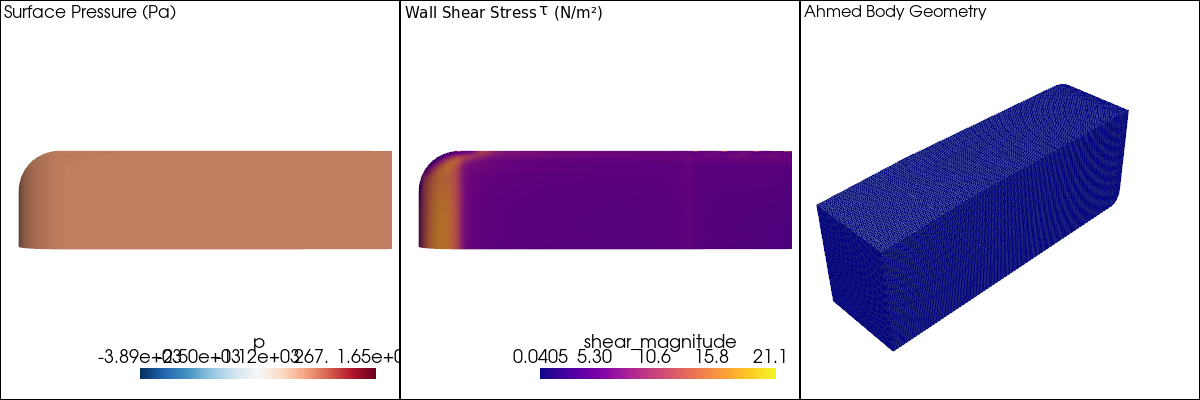

In [7]:
def plot_body_fields(vtp_path: Union[str, Path], window_size=(1200, 400)):
    """
    Four-panel visualization of one Ahmed body simulation:
    surface pressure, wall shear stress magnitude, geometry, and flow arrows.
    """
    mesh = pv.read(vtp_path)

    # Compute per-cell shear magnitude for colouring
    wss = mesh.point_data.get("wallShearStress", np.zeros((mesh.n_points, 3)))
    shear_mag = np.linalg.norm(wss, axis=1)
    mesh.point_data["shear_magnitude"] = shear_mag

    plotter = pv.Plotter(shape=(1, 3), window_size=window_size, off_screen=True)

    # --- Pressure ---
    plotter.subplot(0, 0)
    plotter.add_mesh(mesh, scalars="p", cmap="RdBu_r", show_edges=False)
    plotter.add_text("Surface Pressure (Pa)", font_size=10)
    plotter.camera_position = "xy"

    # --- Wall shear stress magnitude ---
    plotter.subplot(0, 1)
    plotter.add_mesh(mesh, scalars="shear_magnitude", cmap="plasma", show_edges=False)
    plotter.add_text("Wall Shear Stress |τ| (N/m²)", font_size=10)
    plotter.camera_position = "xy"

    # --- Geometry ---
    plotter.subplot(0, 2)
    plotter.add_mesh(mesh, color="lightblue", show_edges=True,
                     edge_color="navy", line_width=0.5)
    plotter.add_text("Ahmed Body Geometry", font_size=10)
    plotter.camera_position = "iso"

    plotter.screenshot("ahmed_body_fields.png")
    plotter.show(jupyter_backend="static")


plot_body_fields(sample_vtp_path)


### Geometry Variation Across Cases

The dataset includes multiple Ahmed body variants with different slant angles and heights. Let's compare a few cases side-by-side to see the geometric variability the model must generalise over.


case10  —  70,661 pts  |  area 0.865 m²
case101  —  76,975 pts  |  area 0.933 m²
case102  —  76,975 pts  |  area 0.933 m²
case105  —  78,129 pts  |  area 0.948 m²


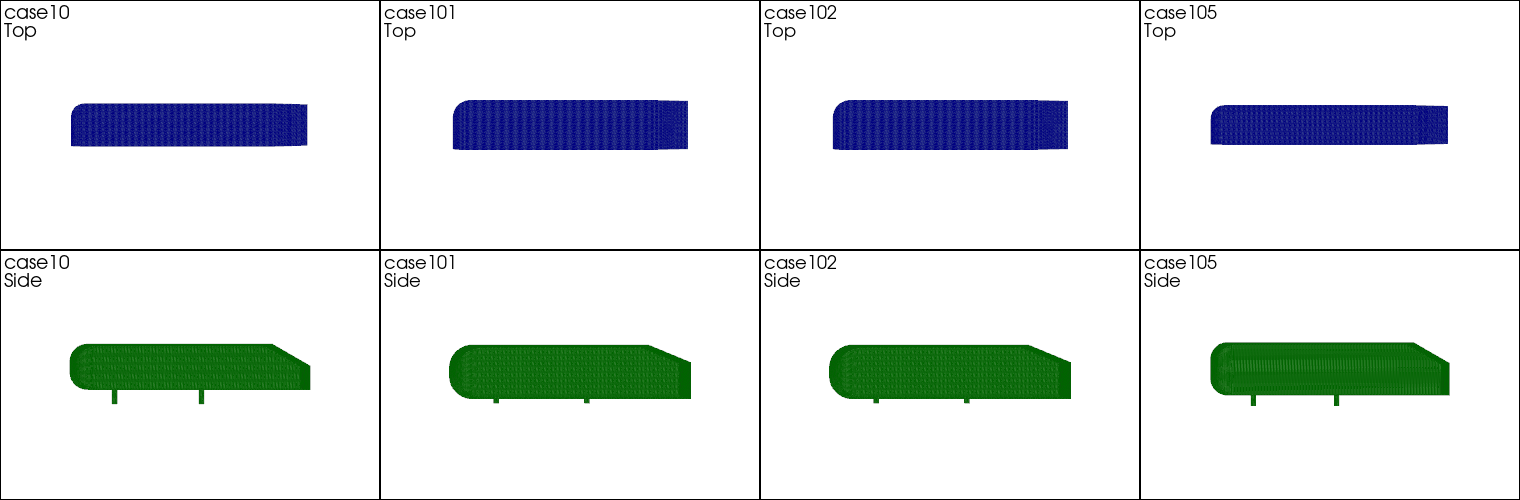

In [8]:
def plot_geometry_comparison(vtp_files: List[Path], titles: Optional[List[str]] = None):
    """Top-view and side-view comparison of several Ahmed body geometries."""
    if titles is None:
        titles = [p.stem for p in vtp_files]
    meshes = [pv.read(f) for f in vtp_files]

    plotter = pv.Plotter(shape=(2, len(meshes)),
                         window_size=(380 * len(meshes), 500),
                         off_screen=True)
    for i, (m, title) in enumerate(zip(meshes, titles)):
        plotter.subplot(0, i)
        plotter.add_mesh(m, color="lightblue", show_edges=True,
                         edge_color="navy", line_width=0.3)
        plotter.add_text(f"{title}\nTop", font_size=9)
        plotter.camera_position = "xy"

        plotter.subplot(1, i)
        plotter.add_mesh(m, color="lightgreen", show_edges=True,
                         edge_color="darkgreen", line_width=0.3)
        plotter.add_text(f"{title}\nSide", font_size=9)
        plotter.camera_position = "xz"

        print(f"{title}  —  {m.n_points:,} pts  |  area {m.area:.3f} m²")

    plotter.screenshot("ahmed_body_comparison.png")
    plotter.show(jupyter_backend="static")


sample_vtps = sorted((DATA_DIR / "train").glob("*.vtp"))[:4]
plot_geometry_comparison(sample_vtps)


## Step 4: VTP / STL → Zarr Conversion

### Physical non-dimensionalization

Before saving, `surface_fields` is divided by $\rho \cdot U^2$ (per-case):

$$C_p = \frac{p}{\rho U^2}, \qquad C_{f,i} = \frac{\tau_{w,i}}{\rho U^2}$$

Result: $C_p \in [-1.2,\, 0.4]$ across all cases — consistent regardless of flow speed.

### What gets saved

| Array | Source | Shape | Saved as | Used by |
|---|---|---|---|---|
| `surface_mesh_centers` | VTP point coords | `(N, 3)` | raw (m) | NB3, NB5 |
| `surface_normals` | VTP point normals | `(N, 3)` | unit vectors | NB3, NB5 |
| `surface_fields` | VTP `p` + `wallShearStress` | `(N, 4)` | **÷ ρU²** | NB3, NB5 |
| `stl_areas` | STL cell areas | `(K,)` | raw (m²) | NB3, NB5 |
| `stl_centers` | STL cell centres | `(K, 3)` | raw (m) | NB3, NB5 |
| `stl_coordinates` | STL **vertices** | `(V, 3)` | raw (m) | **NB5** — GALE |
| `global_params_values` | info file + config | `(2,)` | `[U, ρ]` raw | NB3, NB5 |
| `global_params_reference` | `GLOBAL_PARAMS_REFERENCE` | `(2,)` | `[U_ref, ρ_ref]` | NB3, NB5 |

> **No `air_density` or `stream_velocity` scalar keys** are saved separately.  
> In the training notebooks, `fx = global_params_values / global_params_reference`  
> is computed on the fly — identical to the DoMINO approach.


In [9]:
def process_one_simulation(
    vtp_path:  Path,
    stl_path:  Path,
    info_path: Path,
    zarr_path: Path,
    air_density: float,
    global_params_reference: dict,
) -> bool:
    """
    Convert one VTP + STL + info-file triplet into a Zarr store.

    Physical non-dimensionalization
    --------------------------------
    surface_fields are divided by rho * U² (per-case), giving dimensionless
    Cp and Cf coefficients in the range ~[-1.2, 0.4].

    Global parameter storage (DoMINO convention)
    --------------------------------
    global_params_values    = [stream_velocity, air_density]   raw per-case
    global_params_reference = [U_ref, rho_ref]                 dataset constant

    In the training notebooks, the normalized conditioning input is computed as:
        fx = global_params_values / global_params_reference    (O(1) values)
    """
    try:
        # ── 1. Read per-case inlet velocity from info file ─────────────────────
        stream_velocity = read_velocity_from_info(info_path)

        # ── 2. Compute dynamic pressure for non-dimensionalization ─────────────
        q = air_density * stream_velocity ** 2   # [Pa]

        # ── 3. Process STL geometry ────────────────────────────────────────────
        stl_mesh = pv.get_reader(str(stl_path)).read()

        stl_area_data   = stl_mesh.compute_cell_sizes(length=False, area=True, volume=False)
        stl_areas       = np.array(stl_area_data.cell_data["Area"], dtype=np.float32)
        stl_centers     = np.array(stl_mesh.cell_centers().points,  dtype=np.float32)
        stl_coordinates = np.array(stl_mesh.points,                  dtype=np.float32)

        if stl_areas.shape[0] == 0:
            raise ValueError(f"STL file {stl_path.name} appears empty.")

        # ── 4. Process VTP surface fields ──────────────────────────────────────
        vtp_mesh = pv.read(str(vtp_path))
        surface_mesh_centers = np.array(vtp_mesh.points, dtype=np.float32)

        vtp_mesh.compute_normals(
            cell_normals=False, point_normals=True, auto_orient_normals=True
        )
        surface_normals = np.array(vtp_mesh.point_normals, dtype=np.float32)

        for key in ("p", "wallShearStress"):
            if key not in vtp_mesh.point_data:
                print(f"  [SKIP] {vtp_path.name}: missing '{key}'")
                return False

        pressure = vtp_mesh.point_data["p"]
        wss      = vtp_mesh.point_data["wallShearStress"]

        if pressure.ndim == 1:
            pressure = pressure.reshape(-1, 1)
        if wss.ndim != 2 or wss.shape[1] != 3:
            raise ValueError(f"wallShearStress shape {wss.shape}, expected (N,3)")

        # Stack to (N, 4) then non-dimensionalize by rho * U²
        raw_fields     = np.hstack((pressure, wss)).astype(np.float32)
        surface_fields = (raw_fields / q).astype(np.float32)   # Cp, Cf_x, Cf_y, Cf_z

        # ── 5. Build global_params arrays (DoMINO convention) ─────────────────
        # global_params_values[0] = stream_velocity  (m/s, per-case)
        # global_params_values[1] = air_density      (kg/m³, constant)
        global_params_values = np.array(
            [stream_velocity, air_density], dtype=np.float32
        )
        global_params_reference_arr = np.array(
            [global_params_reference["inlet_velocity"],
             global_params_reference["air_density"]], dtype=np.float32
        )

        # ── 6. Write Zarr store ────────────────────────────────────────────────
        root = zarr.open_group(str(zarr_path), mode="w")

        root.create_array("surface_mesh_centers", data=surface_mesh_centers, chunks=(10_000, 3))
        root.create_array("surface_normals",      data=surface_normals,      chunks=(10_000, 3))
        root.create_array("surface_fields",       data=surface_fields,       chunks=(10_000, 4))

        root.create_array("stl_areas",       data=stl_areas,       chunks=(10_000,))
        root.create_array("stl_centers",     data=stl_centers,     chunks=(10_000, 3))
        root.create_array("stl_coordinates", data=stl_coordinates, chunks=(10_000, 3))

        # Global parameters — raw values + reference (DoMINO pattern)
        # Training notebooks compute: fx = global_params_values / global_params_reference
        root.create_array("global_params_values",    data=global_params_values)
        root.create_array("global_params_reference", data=global_params_reference_arr)

        # Scalar keys required by TransolverDataPipe to build batch["fx"].
        # preprocess_surface_data() checks for "air_density" and "stream_velocity"
        # specifically; without them batch["fx"] is absent.
        root.create_array("air_density",     data=np.float32(air_density))
        root.create_array("stream_velocity", data=np.float32(stream_velocity))

        return True

    except Exception as exc:
        print(f"  [ERROR] {vtp_path.name}: {exc}")
        return False


### Run the Conversion

The Ahmed body dataset already provides `train/`, `validation/`, and `test/` splits.  
We process each folder directly into its own Zarr output directory — no manual  
shuffling or ratio-based splitting, matching the DoMINO preprocessing approach.


In [10]:
def build_zarr_dataset(
    data_dir:   Path,
    zarr_root:  Path,
    air_density: float,
    global_params_reference: dict,
    splits: list = None,
) -> dict:
    """
    Convert all VTP/STL/info triplets for the given splits into Zarr stores.

    Each split (train / validation / test) is read from:
        data_dir / <split>/           (VTP files)
        data_dir / <split>_stl_files/ (STL files)
        data_dir / <split>_info/      (info text files)

    Output is written to:
        zarr_root / <split> / <stem>.zarr

    Returns counts per split: {"train": N, "validation": N, "test": N, "skipped": N}.
    """
    if splits is None:
        splits = ["train", "validation", "test"]

    counts = {s: 0 for s in splits}
    counts["skipped"] = 0

    for split in splits:
        vtp_dir  = data_dir / split
        stl_dir  = data_dir / f"{split}_stl_files"
        info_dir = data_dir / f"{split}_info"
        out_dir  = zarr_root / split
        out_dir.mkdir(parents=True, exist_ok=True)

        vtp_files = sorted(vtp_dir.glob("*.vtp"))
        print(f"\nProcessing '{split}' split ({len(vtp_files)} files) ...")

        for vtp_path in tqdm(vtp_files, desc=f"  {split}"):
            stem     = vtp_path.stem
            stl_path = stl_dir  / f"{stem}.stl"
            inf_path = info_dir / stem
            if not inf_path.exists():
                candidates = list(info_dir.glob(f"{stem}*"))
                inf_path   = candidates[0] if candidates else inf_path

            zarr_path = out_dir / f"{stem}.zarr"
            ok = process_one_simulation(
                vtp_path, stl_path, inf_path, zarr_path,
                air_density, global_params_reference,
            )
            if ok:
                counts[split] += 1
            else:
                counts["skipped"] += 1

    return counts


counts = build_zarr_dataset(
    data_dir                = DATA_DIR,
    zarr_root               = ZARR_OUTPUT_DIR,
    air_density             = AIR_DENSITY,
    global_params_reference = GLOBAL_PARAMS_REFERENCE,
)

print(f"\n=== Conversion complete ===")
for split, n in counts.items():
    if split != "skipped":
        print(f"  {split:12s}: {n} files → {ZARR_OUTPUT_DIR / split}")
print(f"  skipped    : {counts['skipped']}")



Processing 'train' split (408 files) ...


  train: 100%|██████████| 408/408 [06:31<00:00,  1.04it/s]



Processing 'validation' split (50 files) ...


  validation: 100%|██████████| 50/50 [00:48<00:00,  1.03it/s]



Processing 'test' split (50 files) ...


  test: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


=== Conversion complete ===
  train       : 408 files → /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/train
  validation  : 50 files → /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/validation
  test        : 50 files → /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/test
  skipped    : 0


## Step 5: Inspect the Zarr Stores

Let's verify the structure of a freshly written Zarr store before moving on to normalization.


In [12]:
# Pick any Zarr store from the training set
sample_zarr_path = next(TRAIN_ZARR_DIR.glob("*.zarr"))
root = zarr.open_group(str(sample_zarr_path), mode="r")

print(f"Zarr store: {sample_zarr_path.name}\n")
print(f"  {'Array':<26} {'Shape':<14} {'dtype':<10} Range")
print(f"  {'-'*72}")

for key in sorted(root.keys()):
    z = root[key]

    # Skip nested groups, if present
    if isinstance(z, zarr.Group):
        print(f"  {key:<26} {'<group>':<14} {'':<10} -")
        continue

    # [()] reads the full array and also works for 0D scalar arrays.
    # [:] fails for scalar arrays with shape ().
    arr = z[()]

    if arr.shape == ():
        if np.issubdtype(arr.dtype, np.number):
            rng = f"{arr.item():.4f}"
        else:
            rng = str(arr.item())
    elif np.issubdtype(arr.dtype, np.number):
        rng = f"[{arr.min():.4f}, {arr.max():.4f}]"
    else:
        rng = "non-numeric"

    print(f"  {key:<26} {str(arr.shape):<14} {str(arr.dtype):<10} {rng}")


gp_vals = root["global_params_values"][()]      # [U, rho]
gp_ref  = root["global_params_reference"][()]   # [U_ref, rho_ref]
fx_norm = gp_vals / gp_ref

print(
    f"\n  global_params_values    : {gp_vals}"
    f"  → [U={gp_vals[0]:.1f} m/s, rho={gp_vals[1]:.4f} kg/m³]"
)

print(
    f"  global_params_reference : {gp_ref}"
    f"  → [U_ref={gp_ref[0]:.1f} m/s, rho_ref={gp_ref[1]:.3f} kg/m³]"
)

print(
    f"  fx = values/reference   : {fx_norm}  "
    f"(O(1), fed to model as batch['fx'])"
)

sf = root["surface_fields"][()]

print(f"\n  surface_fields (non-dim by rho*U²):")
print(f"    Cp  range: [{sf[:, 0].min():.4f}, {sf[:, 0].max():.4f}]")
print(f"    Cfx range: [{sf[:, 1].min():.4f}, {sf[:, 1].max():.4f}]")


Zarr store: case22.zarr

  Array                      Shape          dtype      Range
  ------------------------------------------------------------------------
  air_density                ()             float32    1.1840
  global_params_reference    (2,)           float32    [1.2260, 60.0000]
  global_params_values       (2,)           float32    [1.1840, 20.0000]
  stl_areas                  (116307,)      float32    [0.0000, 0.0000]
  stl_centers                (116307, 3)    float32    [-0.8690, 0.3280]
  stl_coordinates            (58465, 3)     float32    [-0.8690, 0.3280]
  stream_velocity            ()             float32    20.0000
  surface_fields             (58465, 4)     float32    [-2.4716, 1.1153]
  surface_mesh_centers       (58465, 3)     float32    [-0.8690, 0.3280]
  surface_normals            (58465, 3)     float32    [-1.0000, 1.0000]

  global_params_values    : [20.     1.184]  → [U=20.0 m/s, rho=1.1840 kg/m³]
  global_params_reference : [60.     1.226]  → [U_re

## Step 6: Compute Normalization Statistics

`TransolverDataPipe` z-scores the target `surface_fields` array using per-channel  
mean and standard deviation computed here over the **training split only**.

Because `surface_fields` is already **physically non-dimensionalized** ($C_p$, $C_f$),  
the resulting statistics are tight and consistent across all flow speeds — the  
z-score step is a final fine-tuning rather than the primary normalization.

> Statistics are computed on the **training split only** (`ahmed_body_zarr/train/`)  
> to avoid leaking information about unseen validation and test cases.


In [13]:
# ── Distributed manager (single-GPU / CPU setup) ─────────────────────────────
print("--- COMPUTING NORMALIZATION ---")
os.environ.update({
    "RANK": "0", "WORLD_SIZE": "1",
    "MASTER_ADDR": "localhost", "MASTER_PORT": "12357",
    "LOCAL_RANK": "0",
})
if not DistributedManager.is_initialized():
    DistributedManager.initialize()
dm = DistributedManager()
device = dm.device
print(f"Device: {device}")

# CAEDataset — lightweight zarr reader (only surface_fields needed for stats)
norm_cae = CAEDataset(
    data_dir=str(TRAIN_ZARR_DIR),
    keys_to_read=["surface_fields"],
    keys_to_read_if_available={},
    output_device=torch.device("cpu"),
)
print(f"Computing statistics over {len(norm_cae)} training files ...")

# ── Welford's online algorithm — O(1) memory ─────────────────────────────────
N = 0; mean_acc = M2_acc = min_val = max_val = None

for i in tqdm(range(len(norm_cae)), desc="Welford pass"):
    data = norm_cae[i]["surface_fields"].float()   # (n_pts, 4)  already non-dim
    n    = data.shape[0]

    if mean_acc is None:
        C = data.shape[-1]
        mean_acc = torch.zeros(C)
        M2_acc   = torch.zeros(C)
        min_val  = torch.full((C,), float("inf"))
        max_val  = torch.full((C,), float("-inf"))

    bm = data.mean(dim=0)
    min_val = torch.minimum(min_val, data.amin(dim=0))
    max_val = torch.maximum(max_val, data.amax(dim=0))

    delta    = bm - mean_acc
    N_old    = N
    N       += n
    mean_acc = mean_acc + delta * (n / N)
    M2_acc   = M2_acc + ((data - bm)**2).sum(dim=0) + delta**2 * (n * N_old / N)

std_acc = torch.sqrt(M2_acc / (N - 1))

print("\n=== surface_fields normalization (non-dim values) ===")
channel_names = ["Cp", "Cf_x", "Cf_y", "Cf_z"]
for j, name in enumerate(channel_names):
    print(f"  {name:6s}  mean={mean_acc[j]:8.4f}  std={std_acc[j]:.4f}"
          f"  min={min_val[j]:8.4f}  max={max_val[j]:.4f}")

NORM_FILE = ZARR_OUTPUT_DIR / "surface_fields_normalization.npz"
np.savez(str(NORM_FILE),
         mean=mean_acc.numpy(), std=std_acc.numpy(),
         min=min_val.numpy(),   max=max_val.numpy())
print(f"\nSaved: {NORM_FILE}")
print("--- NORMALIZATION COMPLETE ---")


--- COMPUTING NORMALIZATION ---
Device: cuda:0
Computing statistics over 408 training files ...


Welford pass: 100%|██████████| 408/408 [00:06<00:00, 61.20it/s]


=== surface_fields normalization (non-dim values) ===
  Cp      mean= -0.0896  std=0.1609  min= -4.6121  max=1.6894
  Cf_x    mean= -0.0013  std=0.0009  min= -0.0784  max=0.0060
  Cf_y    mean= -0.0001  std=0.0005  min= -0.0221  max=0.0122
  Cf_z    mean= -0.0000  std=0.0005  min= -0.0161  max=0.0176

Saved: /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/surface_fields_normalization.npz
--- NORMALIZATION COMPLETE ---


### Visualise Field Distributions

Plotting the distribution of each output channel helps catch data issues (outliers, skewed distributions, missing values) before training.


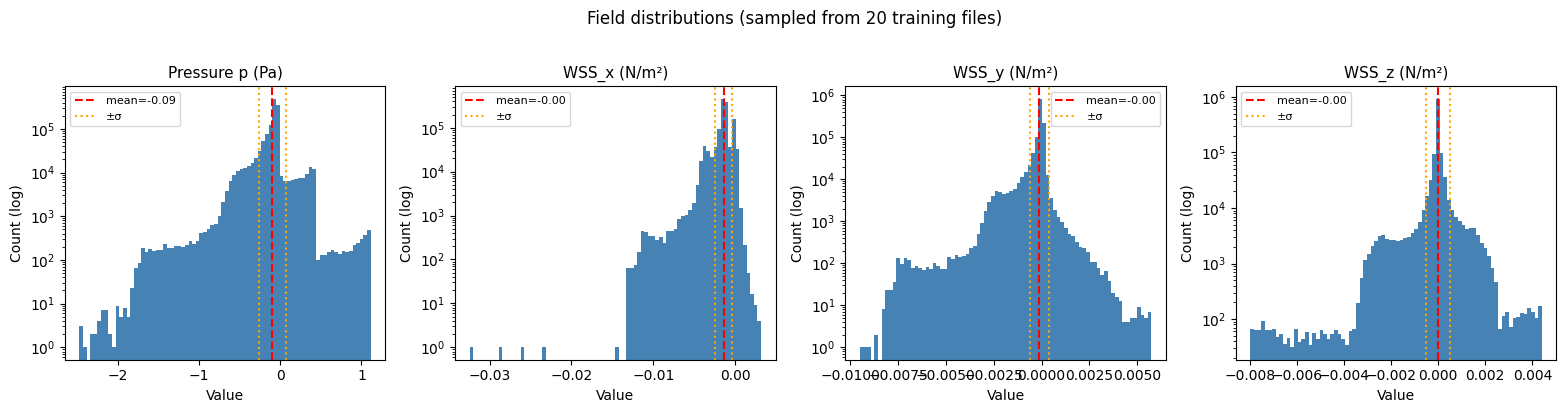

Distribution plots saved to field_distributions.png


In [14]:
# Re-load a few files for a quick distribution check (not the full dataset)
SAMPLE_N = min(20, len(norm_cae))
all_fields = []
for i in range(SAMPLE_N):
    all_fields.append(norm_cae[i]["surface_fields"].numpy())
all_fields = np.concatenate(all_fields, axis=0)   # (total_pts, 4)

channel_names = ["Pressure p (Pa)", "WSS_x (N/m²)", "WSS_y (N/m²)", "WSS_z (N/m²)"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for j, (ax, name) in enumerate(zip(axes, channel_names)):
    vals = all_fields[:, j]
    ax.hist(vals, bins=80, color="steelblue", edgecolor="none", log=True)
    ax.axvline(vals.mean(), color="red",    linestyle="--", label=f"mean={vals.mean():.2f}")
    ax.axvline(vals.mean() + vals.std(), color="orange", linestyle=":", label=f"±σ")
    ax.axvline(vals.mean() - vals.std(), color="orange", linestyle=":")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count (log)")
    ax.legend(fontsize=8)

plt.suptitle(f"Field distributions (sampled from {SAMPLE_N} training files)", y=1.02)
plt.tight_layout()
plt.savefig("field_distributions.png", dpi=100, bbox_inches="tight")
plt.show()
print("Distribution plots saved to field_distributions.png")


## Summary

This notebook has produced everything that Notebooks 3 and 5 need:

| Output | Location | Used by |
|---|---|---|
| Training Zarr stores | `ahmed_body_zarr/train/*.zarr` | NB3, NB5 |
| Validation Zarr stores | `ahmed_body_zarr/validation/*.zarr` | NB3, NB5 |
| Test Zarr stores | `ahmed_body_zarr/test/*.zarr` | optional |
| Normalization file | `ahmed_body_zarr/surface_fields_normalization.npz` | NB3, NB5 |

### Key design decisions

**No manual splitting**  
The dataset ships with `train/`, `validation/`, `test/` folders — we process  
each directly, mirroring the DoMINO preprocessing approach.

**Physical non-dimensionalization**  
`surface_fields` divided by $\rho \cdot U^2$ per case → $C_p \in [-1.2, 0.4]$,  
consistent across all flow speeds before z-score normalization.

**DoMINO-style global parameters**  
`global_params_values = [U, ρ]` (raw per-case) and  
`global_params_reference = [U_ref, ρ_ref]` (dataset constant) saved together.  
Training notebooks compute `fx = global_params_values / global_params_reference` on the fly.

**`stl_coordinates` for GeoTransolver**  
Raw STL vertices in every Zarr store for GALE cross-attention in Notebook 5.

### Next steps

Open **Notebook 3** to train Transolver, or **Notebook 5** to train GeoTransolver.
